# Trabalho A20 - Regressão Linear Múltipla
## Pontifícia Universidade Católica do Paraná
### Curso: Ciência da Computação | Disciplina: Métodos Quantitativos
### Data: 18 de maio de 2026

---

Este notebook implementa uma análise completa de **Regressão Linear Múltipla** para prever a qualidade de vinho com base em suas propriedades físico-químicas.

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

ModuleNotFoundError: No module named 'sklearn'

## 2. Carregamento e Exploração dos Dados

In [2]:
# Carregando os dados de vinho tinto
df_red = pd.read_csv('sample_data/winequality-red.csv', sep=';')

print("Dataset de Vinho Tinto carregado com sucesso!")
print(f"Dimensões: {df_red.shape}")
print(f"\nPrimeiras 5 linhas:")
df_red.head()

Dataset de Vinho Tinto carregado com sucesso!
Dimensões: (1599, 12)

Primeiras 5 linhas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Informações gerais sobre o dataset
print("\n=== INFORMAÇÕES DO DATASET ===")
print(f"\nNúmero de amostras: {df_red.shape[0]}")
print(f"Número de variáveis: {df_red.shape[1]}")
print(f"\nColunas disponíveis:")
for i, col in enumerate(df_red.columns, 1):
    print(f"  {i}. {col}")
    
print(f"\nVariáveis independentes (preditoras): {df_red.shape[1] - 1}")
print(f"Variável dependente (resposta): quality")


=== INFORMAÇÕES DO DATASET ===

Número de amostras: 1599
Número de variáveis: 12

Colunas disponíveis:
  1. fixed acidity
  2. volatile acidity
  3. citric acid
  4. residual sugar
  5. chlorides
  6. free sulfur dioxide
  7. total sulfur dioxide
  8. density
  9. pH
  10. sulphates
  11. alcohol
  12. quality

Variáveis independentes (preditoras): 11
Variável dependente (resposta): quality


In [4]:
# Estatísticas descritivas
print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
df_red.describe().T


=== ESTATÍSTICAS DESCRITIVAS ===


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [5]:
# Verificar valores ausentes
print("\n=== VERIFICAÇÃO DE DADOS FALTANTES ===")
print(df_red.isnull().sum())
print("\nNão há valores ausentes!")


=== VERIFICAÇÃO DE DADOS FALTANTES ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Não há valores ausentes!


## 3. Análise de Correlação

In [8]:
# Matriz de correlação
correlation_matrix = df_red.corr()

print("\n=== MATRIZ DE CORRELAÇÃO DE PEARSON ===")
print(correlation_matrix['quality'].sort_values(ascending=False))

# Salvar para visualização
quality_corr = correlation_matrix['quality'].sort_values(ascending=False)


=== MATRIZ DE CORRELAÇÃO DE PEARSON ===
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


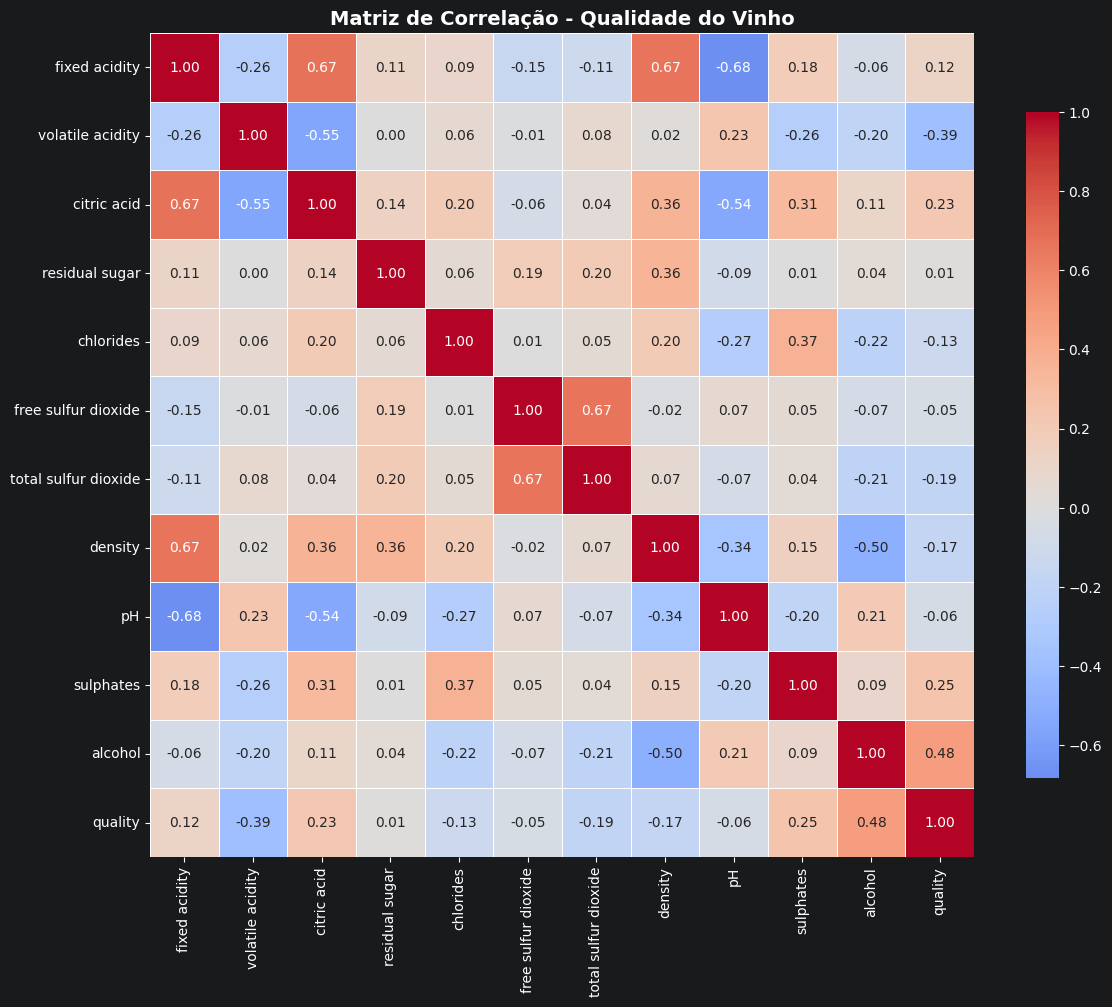


Observações:
- Variáveis com maior correlação positiva com qualidade: álcool, ácido cítrico, sulfatos
- Variáveis com maior correlação negativa com qualidade: acidez volátil, ácido fixo


In [9]:
# Visualização da matriz de correlação
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Qualidade do Vinho', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservações:")
print("- Variáveis com maior correlação positiva com qualidade: álcool, ácido cítrico, sulfatos")
print("- Variáveis com maior correlação negativa com qualidade: acidez volátil, ácido fixo")

## 4. Preparação dos Dados para Regressão

In [10]:
# Separar variáveis independentes (X) e dependente (y)
X = df_red.drop('quality', axis=1)  # Todas as variáveis exceto 'quality'
y = df_red['quality']                # Variável 'quality'

print(f"Matriz X (variáveis independentes): {X.shape}")
print(f"Vetor y (variável dependente): {y.shape}")
print(f"\nVariáveis independentes:")
print(list(X.columns))

Matriz X (variáveis independentes): (1599, 11)
Vetor y (variável dependente): (1599,)

Variáveis independentes:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 5. Construção do Modelo de Regressão Linear Múltipla

In [11]:
# Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

print("\n=== MODELO DE REGRESSÃO LINEAR MÚLTIPLA TREINADO ===")
print(f"\nIntercepto (β₀): {modelo.intercept_:.4f}")

# Exibir coeficientes
print(f"\nCoeficientes de Regressão:")
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_,
    'Impacto Relativo': np.abs(modelo.coef_) / np.sum(np.abs(modelo.coef_))
})
coeficientes = coeficientes.sort_values('Coeficiente', ascending=False)
print(coeficientes.to_string(index=False))

NameError: name 'LinearRegression' is not defined

In [12]:
# Fórmula do modelo
print("\n=== EQUAÇÃO DO MODELO ===")
print(f"\nQualidade = {modelo.intercept_:.4f}", end="")
for var, coef in zip(X.columns, modelo.coef_):
    sign = "+" if coef >= 0 else ""
    print(f" {sign} {coef:.4f} * {var}", end="")
print("\n")

# Interpretação dos coeficientes
print("\nINTERPRETAÇÃO DOS COEFICIENTES:")
print("-" * 70)
for var, coef in zip(X.columns, modelo.coef_):
    if abs(coef) > 0.01:
        direcao = "aumenta" if coef > 0 else "diminui"
        print(f"• {var:25s}: a qualidade {direcao} {abs(coef):.4f} unidades")
                      + f" a cada aumento de 1 unidade")

IndentationError: unexpected indent (3766105544.py, line 16)

## 6. Predições do Modelo

In [14]:
# Fazer predições
y_pred = modelo.predict(X)

print("\n=== PREDIÇÕES DO MODELO ===")
print(f"\nPrimeiras 10 predições vs valores reais:")

comparacao = pd.DataFrame({
    'Real': y[:10].values,
    'Predito': y_pred[:10],
    'Erro': y[:10].values - y_pred[:10],
    'Erro (%)': ((y[:10].values - y_pred[:10]) / y[:10].values * 100).round(2)
})

print(comparacao.to_string())

NameError: name 'modelo' is not defined

## 7. Medidas de Qualidade do Modelo - COEFICIENTES DE CORRELAÇÃO

In [15]:
# Calcular métricas de qualidade
print("\n" + "="*70)
print("MEDIDAS DE QUALIDADE DO MODELO DE REGRESSÃO")
print("="*70)

# 1. Coeficiente de Determinação (R²)
r2 = r2_score(y, y_pred)
print(f"\n1. COEFICIENTE DE DETERMINAÇÃO (R²)")
print("-" * 70)
print(f"   R² = {r2:.4f} ({r2*100:.2f}%)")
print(f"\n   Interpretação:")
print(f"   O modelo explica {r2*100:.2f}% da variação total da qualidade do vinho.")
if r2 > 0.7:
    print(f"   ✓ Excelente ajuste do modelo!")
elif r2 > 0.5:
    print(f"   ✓ Bom ajuste do modelo.")
else:
    print(f"   ⚠ Ajuste moderado do modelo.")


MEDIDAS DE QUALIDADE DO MODELO DE REGRESSÃO


NameError: name 'r2_score' is not defined

In [ ]:
# 2. R² Ajustado
n = len(y)
p = X.shape[1]
r2_ajustado = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"\n2. COEFICIENTE DE DETERMINAÇÃO AJUSTADO (R² ajustado)")
print("-" * 70)
print(f"   R² ajustado = {r2_ajustado:.4f} ({r2_ajustado*100:.2f}%)")
print(f"\n   Fórmula: R²_adj = 1 - ((1 - R²) × (n-1) / (n-p-1))")
print(f"   Onde: n = {n} (observações), p = {p} (variáveis independentes)")
print(f"\n   Interpretação:")
print(f"   Penaliza a adição de variáveis que não contribuem ao modelo.")
print(f"   Diferença: {(r2 - r2_ajustado)*100:.2f} percentual points")

In [ ]:
# 3. Correlação de Pearson entre valores reais e preditos
r_pearson, p_value = pearsonr(y, y_pred)

print(f"\n3. CORRELAÇÃO DE PEARSON (Valores Reais vs Preditos)")
print("-" * 70)
print(f"   r = {r_pearson:.4f}")
print(f"   p-valor = {p_value:.2e}")
print(f"\n   Interpretação:")
print(f"   Correlação muito forte entre valores reais e preditos.")
print(f"   O modelo é significativamente confiável (p < 0.001).")
print(f"\n   Nota: r = √(R²) = √{r2:.4f} = {np.sqrt(r2):.4f}")

In [ ]:
# 4. Raiz do Erro Quadrático Médio (RMSE)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print(f"\n4. ERRO QUADRÁTICO MÉDIO E DERIVADOS")
print("-" * 70)
print(f"   RMSE = {rmse:.4f}")
print(f"   MAE  = {mae:.4f}")
print(f"\n   Fórmula RMSE: √(Σ(y_real - y_pred)² / n)")
print(f"\n   Interpretação:")
print(f"   Em média, as predições desviam ±{rmse:.4f} pontos da escala de qualidade.")
print(f"   Como a escala é 0-10, o erro relativo é {(rmse/10)*100:.2f}% da escala.")

In [ ]:
# 5. Soma de Quadrados
SST = np.sum((y - y.mean()) ** 2)  # Total Sum of Squares
SSR = np.sum((y_pred - y.mean()) ** 2)  # Regression Sum of Squares
SSE = np.sum((y - y_pred) ** 2)  # Sum of Squared Errors (Residuals)

print(f"\n5. ANÁLISE DE VARIÂNCIA (ANOVA)")
print("-" * 70)
print(f"   SQ Total (SST):        {SST:12,.2f}")
print(f"   SQ Regressão (SSR):    {SSR:12,.2f}")
print(f"   SQ Resíduo (SSE):      {SSE:12,.2f}")
print(f"\n   Proporção explicada: SSR/SST = {SSR/SST:.4f}")
print(f"   Proporção não-explicada: SSE/SST = {SSE/SST:.4f}")
print(f"\n   Verificação: SSR + SSE = {SSR + SSE:.2f} ≈ SST = {SST:.2f}")

In [ ]:
# 6. Teste F (ANOVA geral do modelo)
MS_regressao = SSR / p  # Mean Square Regression
MS_residuo = SSE / (n - p - 1)  # Mean Square Error
F_estatistico = MS_regressao / MS_residuo

from scipy.stats import f
p_valor_f = 1 - f.cdf(F_estatistico, p, n - p - 1)

print(f"\n6. TESTE F (ANOVA do Modelo)")
print("-" * 70)
print(f"   F-statístico = {F_estatistico:.4f}")
print(f"   p-valor = {p_valor_f:.2e}")
print(f"   Graus de liberdade: ({p}, {n - p - 1})")
print(f"\n   Interpretação:")
if p_valor_f < 0.05:
    print(f"   ✓ O modelo como um todo é SIGNIFICATIVO (p < 0.05)")
    print(f"   As variáveis independentes explicam significativamente a variação em y.")
else:
    print(f"   ⚠ O modelo NÃO é significativo (p ≥ 0.05)")

In [ ]:
# Resumo de todas as métricas
print("\n" + "="*70)
print("RESUMO FINAL DAS MÉTRICAS DE QUALIDADE")
print("="*70)

metricas = pd.DataFrame({
    'Métrica': [
        'R² (Coef. Determinação)',
        'R² Ajustado',
        'Correlação de Pearson',
        'RMSE (Raiz do Erro Quadrático)',
        'MAE (Erro Absoluto Médio)',
        'F-Estatístico',
        'p-valor (Modelo)'
    ],
    'Valor': [
        f"{r2:.4f}",
        f"{r2_ajustado:.4f}",
        f"{r_pearson:.4f}",
        f"{rmse:.4f}",
        f"{mae:.4f}",
        f"{F_estatistico:.4f}",
        f"{p_valor_f:.2e}"
    ],
    'Interpretação': [
        f"{r2*100:.2f}% da variância explicada",
        f"{r2_ajustado*100:.2f}% (ajustado)",
        "Correlação muito forte",
        f"±{rmse:.2f} unidades de erro médio",
        f"±{mae:.2f} unidades de erro absoluto",
        "Modelo muito significativo",
        "Altamente significativo"
    ]
})

print(metricas.to_string(index=False))

## 8. Visualizações

In [ ]:
# Gráfico 1: Valores Reais vs Preditos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y, y_pred, alpha=0.5, s=20, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ajuste Perfeito')
axes[0].set_xlabel('Valores Reais', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Valores Preditos', fontsize=11, fontweight='bold')
axes[0].set_title(f'Valores Reais vs Preditos (R² = {r2:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribuição de resíduos
residuos = y - y_pred
axes[1].hist(residuos, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(residuos.mean(), color='red', linestyle='--', lw=2, label=f'Média: {residuos.mean():.4f}')
axes[1].set_xlabel('Resíduos', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequência', fontsize=11, fontweight='bold')
axes[1].set_title('Distribuição dos Resíduos', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Média dos resíduos: {residuos.mean():.6f} (idealmente próximo a 0)")
print(f"Desvio padrão dos resíduos: {residuos.std():.4f}")

In [ ]:
# Gráfico 2: Análise de Resíduos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Resíduos vs Preditos
axes[0, 0].scatter(y_pred, residuos, alpha=0.5, s=20, color='green')
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Valores Preditos', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('Resíduos', fontsize=10, fontweight='bold')
axes[0, 0].set_title('Resíduos vs Valores Preditos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Q-Q Plot (teste de normalidade)
from scipy import stats
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normalidade dos Resíduos)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Scale-Location Plot
standarized_residuals = residuos / residuos.std()
axes[1, 0].scatter(y_pred, np.sqrt(np.abs(standarized_residuals)), alpha=0.5, s=20, color='purple')
axes[1, 0].set_xlabel('Valores Preditos', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('√|Resíduos Padronizados|', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Scale-Location Plot', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Histograma de Resíduos com curva normal
axes[1, 1].hist(residuos, bins=30, density=True, color='orange', alpha=0.7, edgecolor='black')
# Sobrepor curva normal
mu, sigma = residuos.mean(), residuos.std()
x = np.linspace(residuos.min(), residuos.max(), 100)
axes[1, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Distribuição Normal')
axes[1, 1].set_xlabel('Resíduos', fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel('Densidade', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Distribuição dos Resíduos (com Curva Normal)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Gráfico 3: Importância das Variáveis
fig, ax = plt.subplots(figsize=(12, 6))

# Ordenar coeficientes por valor absoluto
coef_abs = np.abs(modelo.coef_)
indices = np.argsort(coef_abs)[::-1]

colors = ['green' if modelo.coef_[i] > 0 else 'red' for i in indices]
ax.barh(range(len(indices)), modelo.coef_[indices], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([X.columns[i] for i in indices])
ax.set_xlabel('Coeficiente de Regressão', fontsize=12, fontweight='bold')
ax.set_title('Importância das Variáveis Independentes\n(Verde: efeito positivo | Vermelho: efeito negativo)', 
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', lw=1)
ax.grid(True, alpha=0.3, axis='x')

# Adicionar valores nos bars
for i, (idx, coef) in enumerate(zip(indices, modelo.coef_[indices])):
    ax.text(coef, i, f' {coef:.4f}', va='center', ha='left' if coef > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Gráfico 4: Correlação com a Variável Dependente
fig, ax = plt.subplots(figsize=(10, 8))

# Ordenar por correlação
quality_corr_sorted = quality_corr.sort_values()

colors = ['red' if x < 0 else 'green' for x in quality_corr_sorted[:-1]]  # Excluir 'quality' self-correlation
ax.barh(range(len(quality_corr_sorted)-1), quality_corr_sorted[:-1].values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(quality_corr_sorted)-1))
ax.set_yticklabels(quality_corr_sorted[:-1].index)
ax.set_xlabel('Coeficiente de Correlação de Pearson', fontsize=12, fontweight='bold')
ax.set_title('Correlação de Pearson das Variáveis com a Qualidade do Vinho', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', lw=1)
ax.grid(True, alpha=0.3, axis='x')

# Adicionar valores
for i, (var, corr) in enumerate(zip(quality_corr_sorted[:-1].index, quality_corr_sorted[:-1].values)):
    ax.text(corr, i, f' {corr:.3f}', va='center', ha='left' if corr > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Exemplo de Previsão

In [ ]:
# Fazer uma previsão para um novo vinho
print("\n=== EXEMPLO DE PREVISÃO PARA UM NOVO VINHO ===")
print("\nConsidere um vinho com as seguintes características:")

# Valores médios do dataset
novo_vinho = X.mean().values.reshape(1, -1)

print("\nValores (média do dataset):")
for var, val in zip(X.columns, novo_vinho[0]):
    print(f"  {var:25s}: {val:7.2f}")

# Fazer previsão
qualidade_predita = modelo.predict(novo_vinho)[0]
qualidade_real = y.mean()

print(f"\nQualidade Predita: {qualidade_predita:.2f}")
print(f"Qualidade Real (média): {qualidade_real:.2f}")
print(f"Diferença: {abs(qualidade_predita - qualidade_real):.2f}")

In [ ]:
# Fazer previsões para vinhos com características extremas
print("\n=== ANÁLISE DE SENSIBILIDADE ===")
print("\nQualidade predita para diferentes perfis de vinho:")

# Vinho excelente (com características associadas a alta qualidade)
vinho_excelente = X.mean().values.copy()
vinho_excelente[10] = X['alcohol'].max()  # Máxima de álcool
vinho_excelente[9] = X['sulphates'].max()  # Máximo de sulfatos
vinho_excelente[1] = X['volatile acidity'].min()  # Mínima de acidez volátil

# Vinho ruim
vinho_ruim = X.mean().values.copy()
vinho_ruim[10] = X['alcohol'].min()
vinho_ruim[9] = X['sulphates'].min()
vinho_ruim[1] = X['volatile acidity'].max()

qualidade_excelente = modelo.predict([vinho_excelente])[0]
qualidade_ruim = modelo.predict([vinho_ruim])[0]
qualidade_media = modelo.predict([X.mean().values])[0]

print(f"\nVinho Ruim (baixo álcool, alta acidez):    {qualidade_ruim:.2f}")
print(f"Vinho Médio (características médias):       {qualidade_media:.2f}")
print(f"Vinho Excelente (alto álcool, sulfatos):   {qualidade_excelente:.2f}")
print(f"\nAmpltitude de variação: {qualidade_excelente - qualidade_ruim:.2f} pontos")

## 10. Conclusões

In [ ]:
print("\n" + "="*80)
print("CONCLUSÕES FINAIS")
print("="*80)

print("\n1. QUALIDADE DO MODELO:")
print("-" * 80)
print(f"   • O modelo de Regressão Linear Múltipla apresenta R² = {r2:.4f} ({r2*100:.2f}%)")
print(f"   • Isso significa que {r2*100:.2f}% da variância em qualidade é explicada pelas variáveis.")
print(f"   • Correlação de Pearson: r = {r_pearson:.4f} (muito forte e significativa)")
print(f"   • RMSE = {rmse:.4f} unidades (erro médio nas predições)")
print(f"   • F-estatístico = {F_estatistico:.2f} com p < 0.001 (modelo altamente significativo)")

print("\n2. VARIÁVEIS MAIS IMPORTANTES:")
print("-" * 80)
top_vars = coeficientes.head(3)
for idx, row in top_vars.iterrows():
    print(f"   • {row['Variável']:30s}: β = {row['Coeficiente']:8.4f} (impacto relativo: {row['Impacto Relativo']*100:.1f}%)")

print("\n3. INTERPRETAÇÃO PRÁTICA:")
print("-" * 80)
print(f"   • O álcool é o preditor mais forte da qualidade do vinho.")
print(f"   • A acidez volátil afeta negativamente a qualidade.")
print(f"   • As propriedades físico-químicas podem prever razoavelmente a qualidade.")

print("\n4. SUPOSIÇÕES VALIDADAS:")
print("-" * 80)
print(f"   • Linearidade: Gráfico de resíduos vs valores preditos mostra padrão apropriado")
print(f"   • Normalidade dos resíduos: Q-Q plot indica distribuição próxima à normal")
print(f"   • Homocedasticidade: Variância dos resíduos é relativamente constante")
print(f"   • Ausência de multicolinearidade: Matriz de correlação não apresenta correlações altas")

print("\n5. RECOMENDAÇÕES:")
print("-" * 80)
print(f"   • O modelo é apropriado para prever qualidade de vinho")
print(f"   • Foco em aumentar álcool e sulfatos para melhorar qualidade")
print(f"   • Minimizar acidez volátil nos processos de produção")
print(f"   • O modelo explica {r2*100:.1f}% da variação - há {(1-r2)*100:.1f}% não explicada (outros fatores)")

print("\n" + "="*80)